# CHAOS — raw data exploration (abdominal organ segmentation)

Reads the **raw** Zenodo `CHAOS_Train_Sets` download. This one is 3-D DICOM series, so a
"sample" here is **one axial slice** of a patient volume.

Layout:
* `Train_Sets/CT/<pid>/DICOM_anon/*.dcm`  + `Ground/liver_GT_*.png`
  — CT, 512×512 `uint16`, **liver only** (binary). HU = `pixel*RescaleSlope + RescaleIntercept`.
* `Train_Sets/MR/<pid>/T2SPIR/DICOM_anon/*.dcm` + `Ground/*.png`
  — MR T2-SPIR, 256×256, **4 organs**.
* `Train_Sets/MR/<pid>/T1DUAL/DICOM_anon/{InPhase,OutPhase}/*.dcm` + `Ground/*.png`
  — MR T1 dual-echo; one GT shared by both phases.

MR ground-truth PNGs are a grayscale-encoded class map:
`0 background, 63 liver, 126 right kidney, 189 left kidney, 252 spleen`
(the official tolerance bands are 55-70 / 110-135 / 175-200 / 240-255).

Pairing: DICOM sorted **by filename** ↔ Ground sorted by filename, index-for-index
(the documented CHAOS correspondence — note SimpleITK's geometric series order is
*reversed* vs. this, so we read slices individually with pydicom).

Set `MODALITY` in the config cell to `'CT'`, `'MR_T2SPIR'`, or `'MR_T1DUAL_In'` /
`'MR_T1DUAL_Out'` and re-run.

In [2]:
import os, glob
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

import pydicom

_CAND = ['../../data/CHAOS/raw', 'data_handlers/data/CHAOS/raw', '../data_handlers/data/CHAOS/raw']
RAW = next((p for p in _CAND if os.path.isdir(p)), _CAND[0])
TRAIN = os.path.join(RAW, 'Train_Sets')
print('raw root :', os.path.abspath(RAW), '| exists:', os.path.isdir(TRAIN))

# ── pick one ─────────────────────────────────────────────
MODALITY = 'CT'   # 'CT' | 'MR_T2SPIR' | 'MR_T1DUAL_In' | 'MR_T1DUAL_Out'
# ─────────────────────────────────────────────────────────

_CFG = {
    'CT':           dict(root='CT',  sub='DICOM_anon',            gt='Ground', hu=True),
    'MR_T2SPIR':    dict(root='MR',  sub='T2SPIR/DICOM_anon',     gt='T2SPIR/Ground', hu=False),
    'MR_T1DUAL_In': dict(root='MR',  sub='T1DUAL/DICOM_anon/InPhase',  gt='T1DUAL/Ground', hu=False),
    'MR_T1DUAL_Out':dict(root='MR',  sub='T1DUAL/DICOM_anon/OutPhase', gt='T1DUAL/Ground', hu=False),
}[MODALITY]

if MODALITY == 'CT':
    CLASS_NAMES = ['background', 'liver']
    MR_GT_LEVELS = None
else:
    CLASS_NAMES = ['background', 'liver', 'right kidney', 'left kidney', 'spleen']
    MR_GT_LEVELS = [0, 63, 126, 189, 252]   # -> class 0..4

DATASET_NAME  = f'CHAOS [{MODALITY}]'
SPLIT_NOTE    = 'Train_Sets only; one row per axial slice'
LAYOUT_NOTE   = '(H, W) single-channel slice from a 3-D DICOM series'
INTENSITY_NOTE = '(Hounsfield units)' if _CFG['hu'] else '(raw MR scanner intensity, arbitrary units)'
CHANNEL_NAMES = ['HU' if _CFG['hu'] else 'intensity']
RAW_LABEL_NOTE = ('bool liver PNG' if MODALITY == 'CT'
                  else 'grayscale PNG levels 0/63/126/189/252 -> class 0-4')

raw root : /mnt/mydrive/ilias/projects/unsupervised_learning/ICLR/ICLR/data_handlers/data/CHAOS/raw | exists: True


In [3]:
CLASS_COLORS = np.array([
    [0.00, 0.00, 0.00],  # 0 background
    [0.90, 0.20, 0.20],  # 1
    [0.20, 0.55, 0.95],  # 2
    [0.20, 0.80, 0.35],  # 3
    [0.95, 0.75, 0.15],  # 4
    [0.75, 0.35, 0.85],  # 5
], dtype=np.float32)
CLASS_CMAP = ListedColormap(CLASS_COLORS[:len(CLASS_NAMES)])

## Loading helpers

One `(patient, slice)` pair per sample.

In [4]:
def _patients():
    p = os.path.join(TRAIN, _CFG['root'])
    return sorted((d for d in os.listdir(p) if os.path.isdir(os.path.join(p, d))), key=int)

def _dcm_files(pid):
    return sorted(glob.glob(os.path.join(TRAIN, _CFG['root'], pid, _CFG['sub'], '*.dcm')))

def _gt_files(pid):
    return sorted(glob.glob(os.path.join(TRAIN, _CFG['root'], pid, _CFG['gt'], '*.png')))

def list_ids():
    """(pid, slice_index) for every slice that has both a DICOM and a GT PNG."""
    ids = []
    for pid in _patients():
        n = min(len(_dcm_files(pid)), len(_gt_files(pid)))
        ids += [(pid, i) for i in range(n)]
    return ids

def _read_dcm(path):
    ds = pydicom.dcmread(path)
    a = ds.pixel_array.astype(np.float32)
    if _CFG['hu']:
        a = a * float(getattr(ds, 'RescaleSlope', 1)) + float(getattr(ds, 'RescaleIntercept', 0))
    return a

def lab_raw(sid):
    from PIL import Image
    pid, i = sid
    return np.array(Image.open(_gt_files(pid)[i]))

def _gt_to_classes(m):
    if MR_GT_LEVELS is None:
        return (m > 0).astype(np.int64)
    out = np.zeros(m.shape, np.int64)
    for cls, lvl in enumerate(MR_GT_LEVELS):
        if cls == 0:
            continue
        out[np.abs(m.astype(np.int32) - lvl) <= 8] = cls
    return out

def load_sample(sid):
    """(image, label). image: (H,W) float32 (HU or raw MR). label: (H,W) int class map."""
    pid, i = sid
    img = _read_dcm(_dcm_files(pid)[i])
    lab = _gt_to_classes(lab_raw(sid))
    return img, lab

print(len(_patients()), 'patients |', len(list_ids()), 'slices total')

20 patients | 2874 slices total


## Numeric report

Dimensions · per-channel min/max/mean · number of labels · per-label area %.

`report(n=400)` subsamples slices; drop the arg for everything.

In [5]:
def report(n=None, seed=0):
    """Numeric summary over the dataset (n=None -> all samples; int -> random subset).
    Reports: dimensions, per-channel min/max/mean, #labels, per-label area %."""
    ids = list_ids()
    if n is not None and n < len(ids):
        sel = np.random.default_rng(seed).choice(len(ids), size=n, replace=False)
        ids = [ids[k] for k in sel]   # index-based: ids may be tuples (CHAOS)

    shapes, chan_stats, areas = [], [], []
    raw_label_values = set()
    for sid in ids:
        img, lab = load_sample(sid)
        shapes.append(tuple(img.shape))
        x = img.reshape(-1, img.shape[2] if img.ndim == 3 else 1).astype(np.float64)
        chan_stats.append((x.min(0), x.max(0), x.mean(0)))
        areas.append([float((lab == c).mean()) for c in range(len(CLASS_NAMES))])
        raw_label_values |= set(np.unique(lab_raw(sid)).astype(int).tolist())
    areas = np.array(areas)
    cmin = np.min([s[0] for s in chan_stats], axis=0)
    cmax = np.max([s[1] for s in chan_stats], axis=0)
    cmean = np.mean([s[2] for s in chan_stats], axis=0)

    hs = np.array([s[0] for s in shapes]); ws = np.array([s[1] for s in shapes])
    print(f"{DATASET_NAME} — inspected {len(ids)} samples ({SPLIT_NOTE})\n")
    print("DIMENSIONS")
    print(f"  image ndim/layout : {LAYOUT_NOTE}")
    print(f"  H range           : [{hs.min()}, {hs.max()}]     W range: [{ws.min()}, {ws.max()}]")
    print(f"  distinct shapes   : {len(set(shapes))}   e.g. {sorted(set(shapes))[:4]}")
    print(f"  mask layout       : (H, W) int class-index map, same H/W as its image\n")
    print("PER-CHANNEL INTENSITY  " + INTENSITY_NOTE)
    print(f"  {'channel':<10}{'min':>12}{'max':>12}{'mean':>12}")
    for i, cn in enumerate(CHANNEL_NAMES):
        print(f"  {cn:<10}{cmin[i]:>12.2f}{cmax[i]:>12.2f}{cmean[i]:>12.2f}")
    print()
    print("LABELS")
    print(f"  number of labels  : {len(CLASS_NAMES)}  ->  "
          + ", ".join(f"{i}={n}" for i, n in enumerate(CLASS_NAMES)))
    print(f"  raw values on disk: {sorted(raw_label_values)}  ({RAW_LABEL_NOTE})\n")
    print(f"  {'class':<16}{'mean area %':>14}{'present in':>16}")
    for c in range(len(CLASS_NAMES)):
        present = int((areas[:, c] > 0).sum())
        print(f"  {CLASS_NAMES[c]:<16}{100 * areas[:, c].mean():>13.3f}%{present:>10}/{len(ids)}")

In [6]:
report(n=400, seed=0)

CHAOS [CT] — inspected 400 samples (Train_Sets only; one row per axial slice)

DIMENSIONS
  image ndim/layout : (H, W) single-channel slice from a 3-D DICOM series
  H range           : [512, 512]     W range: [512, 512]
  distinct shapes   : 1   e.g. [(512, 512)]
  mask layout       : (H, W) int class-index map, same H/W as its image

PER-CHANNEL INTENSITY  (Hounsfield units)
  channel            min         max        mean
  HU            -1200.00    49944.00     -492.34

LABELS
  number of labels  : 2  ->  0=background, 1=liver
  raw values on disk: [0, 1]  (bool liver PNG)

  class              mean area %      present in
  background             93.607%       400/400
  liver                   6.393%       333/400


## Visual check — 4 random samples

image | mask | overlay. Restricted to slices that actually contain an organ (`_fg_ids()`), so you don't land on empty end-slices.

In [7]:
def _to_disp(img):
    """Anything -> float array in [0,1] for imshow. (H,W) or (H,W,3). 1-99 pct window."""
    img = np.asarray(img, dtype=np.float64)
    lo, hi = np.nanpercentile(img, [1, 99]) if img.size else (0, 1)
    if hi <= lo:
        lo, hi = float(np.nanmin(img)), float(np.nanmax(img)) or 1.0
    return np.clip((img - lo) / (hi - lo + 1e-9), 0, 1)


def show_samples(n=4, seed=0, ids=None):
    """image | colour-coded mask | overlay, for n random samples.
    ids: optional explicit id pool (defaults to list_ids())."""
    pool = list(ids) if ids is not None else list_ids()
    idx = np.random.default_rng(seed).choice(len(pool), size=min(n, len(pool)), replace=False)
    picks = [pool[i] for i in idx]
    fig, axs = plt.subplots(len(picks), 3, figsize=(11, 3.6 * len(picks)))
    axs = np.atleast_2d(axs)
    for r, sid in enumerate(picks):
        img, lab = load_sample(sid)
        disp = _to_disp(img)
        axs[r, 0].imshow(disp, cmap=None if disp.ndim == 3 else "gray")
        axs[r, 1].imshow(CLASS_COLORS[lab])
        axs[r, 2].imshow(disp, cmap=None if disp.ndim == 3 else "gray")
        fg = lab != 0
        axs[r, 2].imshow(np.dstack([CLASS_COLORS[lab], 0.45 * fg]))
        axs[r, 0].set_ylabel(str(sid), fontsize=8)
        for c in range(3):
            axs[r, c].set_xticks([]); axs[r, c].set_yticks([])
    for c, t in enumerate(["image", "mask", "overlay"]):
        axs[0, c].set_title(t)
    handles = [Patch(facecolor=CLASS_COLORS[i], edgecolor="k", label=f"{i} {CLASS_NAMES[i]}")
               for i in range(len(CLASS_NAMES))]
    axs[0, 1].legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, 1.12),
                     ncol=len(CLASS_NAMES), fontsize=8, frameon=False)
    plt.tight_layout()
    plt.show()

2341 slices with foreground


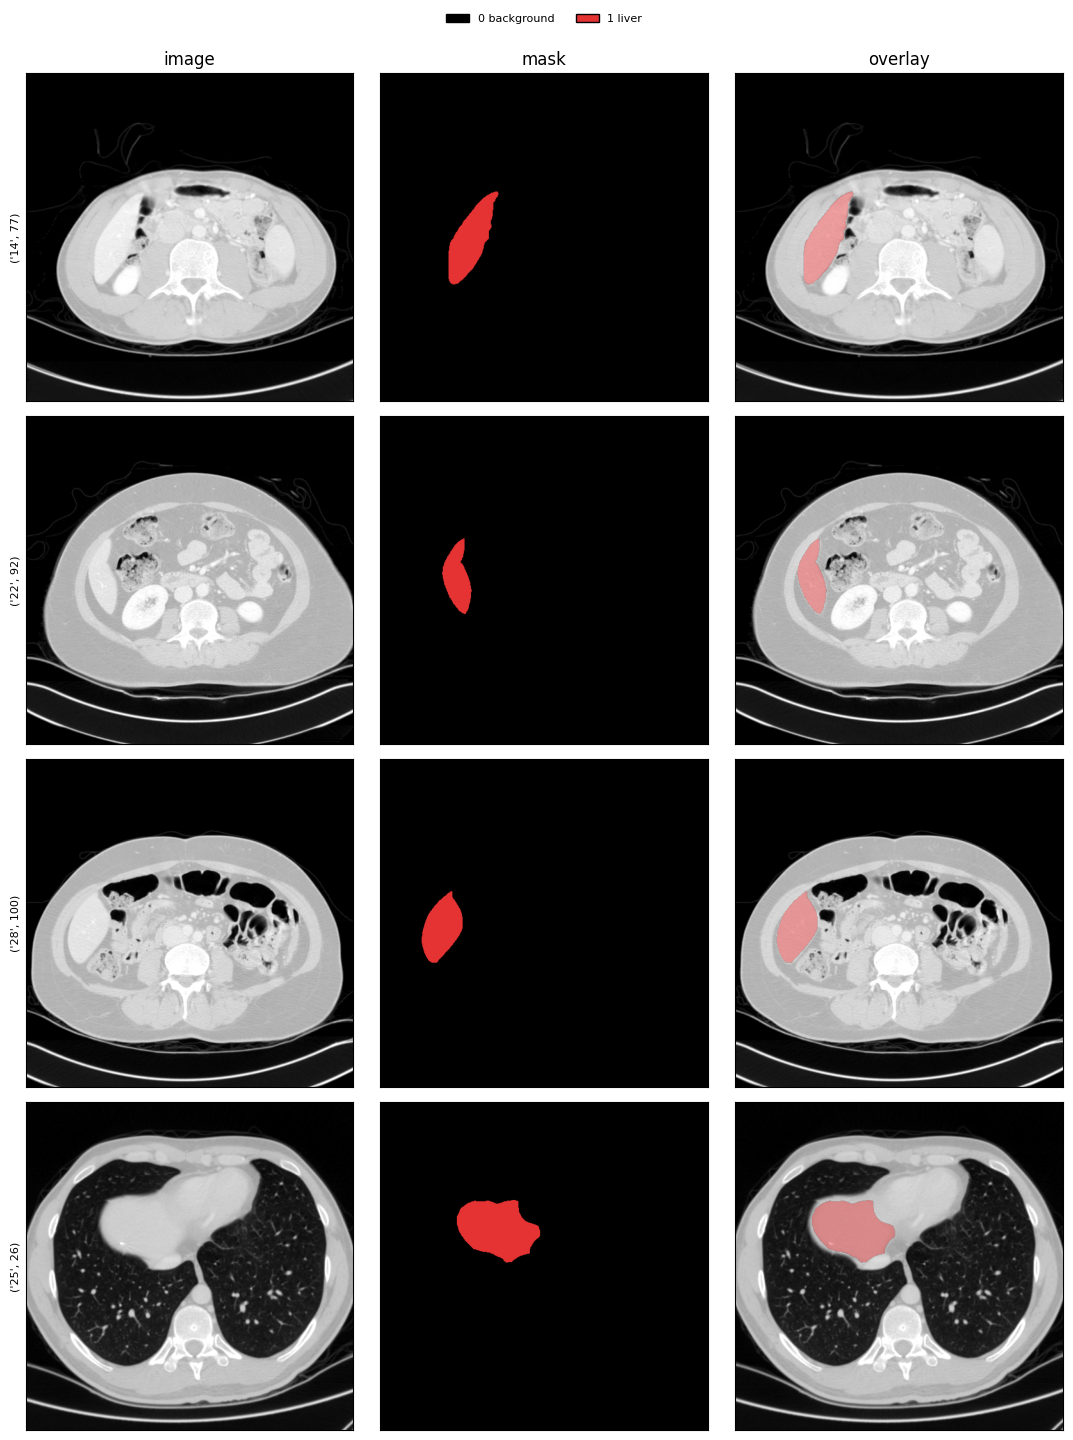

In [8]:
def _fg_ids():
    """ids whose GT has any foreground — so the 4 samples aren't all empty end-slices."""
    out = [sid for sid in list_ids() if _gt_to_classes(lab_raw(sid)).any()]
    return out or list_ids()

print(len(_fg_ids()), 'slices with foreground')
show_samples(n=4, seed=0, ids=_fg_ids())

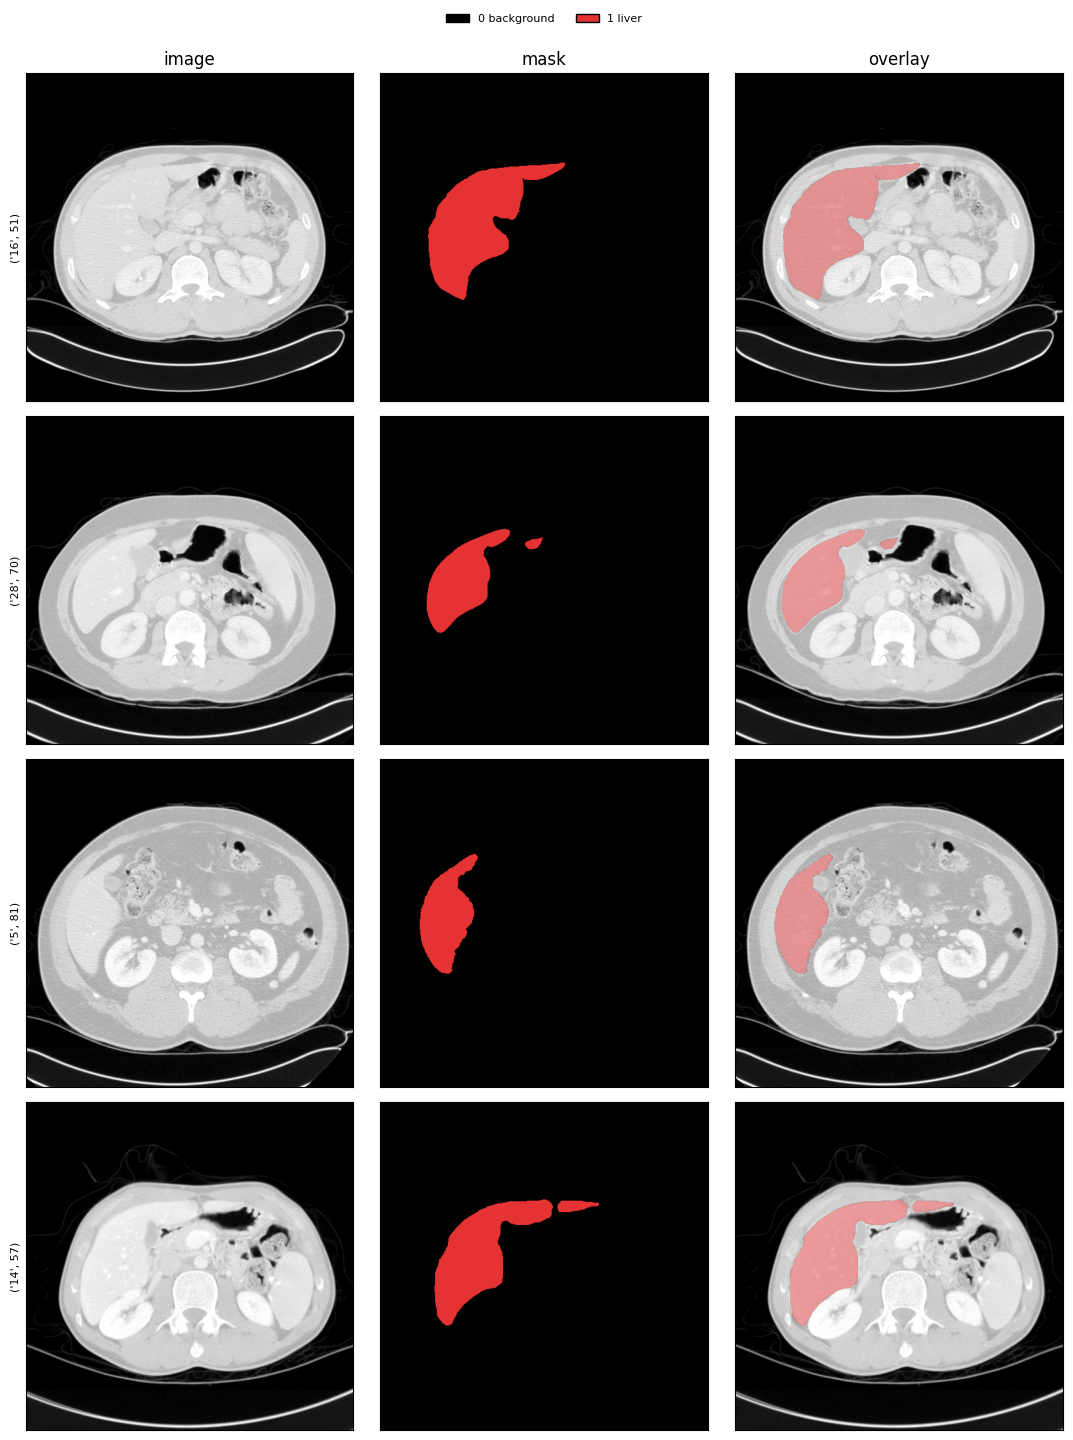

In [9]:
show_samples(n=4, seed=2, ids=_fg_ids())